# 모델·데이터·평가 보고서 — 4조

LoL 경기는 언제 승부가 결정되는가 — 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석

| | 내용 |
|---|---|
| **1** | 팀에서 채택한 모델 |
| **2** | 학습/테스트 데이터 뷰와 분할 상태 |
| **3** | 테스트 데이터 평가 결과 |
| **4** | 혼동행렬 (confusion matrix) |

위에서부터 실행하면 모든 수치가 재현됩니다. (Python 3.11 · scikit-learn 1.9.0 · 시드 42)

In [1]:
%matplotlib inline
import os, json, sys, warnings
from pathlib import Path

_p = Path.cwd()                       # 어디서 열든 프로젝트 폴더 기준으로 맞춘다
for _ in range(6):
    if (_p / "artifacts").is_dir() and (_p / "predict.py").is_file():
        os.chdir(_p); break
    _p = _p.parent

import joblib, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")
from finalize_model import DIFF13, load_data

matplotlib.use("module://matplotlib_inline.backend_inline")   # finalize_model 이 Agg 로 바꾸므로 되돌린다
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f; break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
print("준비 완료 —", os.getcwd())

준비 완료 — C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석


---
## 1. 팀에서 채택한 모델

**로지스틱 회귀** (`StandardScaler` + `LogisticRegression`을 Pipeline 하나로 저장)

10분 시점의 상황 13개를 넣으면 **파란 팀이 이길 확률**을 돌려주고, 0.5 이상이면 승리로 판정합니다.
계산은 두 단계입니다 — ① 각 지표에 가중치를 곱해 더하고 ② 그 값을 0~1 확률로 바꿉니다.
**이 가중치가 곧 해석**이라, 어떤 지표가 승패에 얼마나 작용했는지 그대로 읽을 수 있습니다.

### 왜 이 모델인가 — 후보 8개를 같은 조건에서 비교 (5조각 교차검증, 시드 42)

| 모델 | 교차검증 정확도 | 연습−검증 격차 | 판정 |
|---|---|---|---|
| **로지스틱 회귀** | **0.7280 ± 0.0163** | **+0.0039** | ✅ 채택 |
| 랜덤포레스트 | 0.7248 | +0.2752 (연습 1.0000) | ❌ 통째로 외움 |
| GaussianNB | 0.7238 | +0.0015 | 2위 이하 |
| SVM (RBF) | 0.7223 | +0.0391 | ❌ 기준 초과 |
| 결정트리 · KNN · HistGB | 0.7140~0.7180 | 최대 +0.1387 | ❌ / 하위 |
| 찍기 (기준선) | 0.5009 | — | 비교 출발선 |

**성능이 모델 복잡도의 역순이었습니다.** 랜덤포레스트는 연습 점수가 만점(1.0000)인데
처음 보는 데이터에서 0.7248로 떨어집니다. 외운 것이지 배운 게 아닙니다.

로지스틱을 고른 이유는 ① 점수 1위 ② 외우지 않음 ③ **가중치로 "왜"를 설명할 수 있음** 입니다.

**튜닝은 하지 않았습니다.** 골드차 1개만 넣어도 0.7313, 골드차+경험치차 2개면 0.7328로
전체와 거의 같습니다. 정보가 두 지표에 몰려 있어 조정해도 짜낼 것이 없습니다.
판정 기준값도 0.40~0.60을 훑어본 결과 평평해서 **기본값 0.5**를 그대로 씁니다.

In [2]:
model = joblib.load("artifacts/model.joblib")
schema = json.load(open("artifacts/schema.json", encoding="utf-8"))
lr = model.named_steps["model"]

print("Pipeline 구성:", " → ".join(type(s).__name__ for s in model.named_steps.values()))
print(f"입력 지표 {len(schema['features'])}개 · 시점 {schema['time_point_min']}분 · 시드 {schema['seed']}")
print(f"scikit-learn {schema['sklearn_version']} · 절편 {lr.intercept_[0]:.4f}")

coef = pd.Series(lr.coef_[0], index=DIFF13).sort_values(key=abs, ascending=False)
display(coef.round(4).to_frame("표준화 계수").T)

Pipeline 구성: StandardScaler → LogisticRegression
입력 지표 13개 · 시점 10분 · 시드 42
scikit-learn 1.9.0 · 절편 -0.0043


,GoldDiff,ExpDiff,DragonsDiff,TotalMinionsKilledDiff,KillsDiff,AssistsDiff,TowersDestroyedDiff,HeraldsDiff,FirstBlood,WardsPlacedDiff,WardsDestroyedDiff,AvgLevelDiff,TotalJungleMinionsKilledDiff
표준화 계수,1.2314,0.461,0.2674,-0.1574,-0.1067,-0.0785,-0.0643,0.0505,0.035,-0.0159,0.0094,0.0084,-0.0003


> 킬 차이의 계수가 음수인데 "킬하면 진다"는 뜻이 아닙니다. 킬을 하면 돈을 받으므로
> 킬의 가치가 이미 골드 차이에 들어가 있어(상관 +0.92), 골드를 아는 모델에게 킬은 더 보탤 정보가 없다는 뜻입니다.

---
## 2. 학습/테스트 데이터 뷰와 분할 상태

### 원천 데이터

Kaggle 다이아 랭크 10분 스냅샷 **9,879행 × 40컬럼** (한 행 = 경기 한 판), 팀 MariaDB `lol_matches_10min`에 적재.
**결측 0건 · 중복 0건 · 승패 50.10 : 49.90** (거의 반반이라 정확도를 1순위 지표로 쓰는 것이 정당합니다).

### 뷰 구성

피처 계산식은 **SQL 뷰 한 곳에만** 두고 파이썬은 읽기만 합니다 (`db/create_ml_views.sql`).

```
lol_matches_10min ─┬─ ml_split (분할 고정)
                   └─→ v_base ─→ v_diff13_all ─┬─ v_diff13_train (7,903행)
                                                └─ v_diff13_test  (1,976행)
```

| 뷰 | 지표 수 | 용도 |
|---|---|---|
| **`v_diff13_train` / `_test`** | **13** | **채택** — 학습·평가에 사용 |
| `v_clean27_train` / `_test` | 27 | 중복만 제거한 대조군 |
| `v_gold2_train` / `_test` | 2 | 최소 구성 기준선 |
| `v_cluster5_train` / `_test` | 5 | 경기 유형 분류 전용 (비지도, 예측에 미사용) |

뷰가 4종이라고 모델이 4개인 게 아니라, **하나의 모델에 넣을 재료 묶음**을 바꿔 비교한 것입니다.
학습에는 `_train`만 쓰고 `_test`는 최종 채점에서 한 번만 엽니다.

**지표 13개는 "파란 팀 − 빨간 팀" 차이값**입니다. 원본 38개 중 11개가 중복(거울 컬럼·상수배·합계 컬럼)이라
지우고 차이값으로 합쳤더니, 지표는 절반인데 정확도는 올랐습니다(0.7334 → 0.7369).

In [3]:
X_tr, y_tr, X_te, y_te, source = load_data()      # 저장된 분할을 그대로 사용

display(pd.DataFrame({
    "경기 수": [f"{len(y_tr):,}", f"{len(y_te):,}", f"{len(y_tr)+len(y_te):,}"],
    "비율": ["80%", "20%", "100%"],
    "승리 비율": [f"{y_tr.mean():.4f}", f"{y_te.mean():.4f}",
                  f"{(y_tr.sum()+y_te.sum())/(len(y_tr)+len(y_te)):.4f}"],
}, index=["학습(train)", "시험(test)", "전체"]))

print(f"데이터 출처: {source}   (DB 접속 정보가 없으면 같은 계산식의 CSV 로 자동 전환)")
print(f"학습·시험 겹치는 경기: {len(set(X_tr.index) & set(X_te.index))}건   ← 0 이어야 정상")
print()
print("분할 고정 방법")
print("  · 층화 분할 stratify=y · 시드 42 · test_size=0.2")
print("  · data/splits/train_idx.csv · test_idx.csv 에 저장, DB 는 ml_split 테이블")
print("  · 행 정렬을 gameId 순으로 고정 (순서가 다르면 같은 시드라도 분할이 달라짐)")

,경기 수,비율,승리 비율
학습(train),"7,903",80%,0.4991
시험(test),"1,976",20%,0.4990
전체,"9,879",100%,0.4990


데이터 출처: csv:fallback   (DB 접속 정보가 없으면 같은 계산식의 CSV 로 자동 전환)
학습·시험 겹치는 경기: 0건   ← 0 이어야 정상

분할 고정 방법
  · 층화 분할 stratify=y · 시드 42 · test_size=0.2
  · data/splits/train_idx.csv · test_idx.csv 에 저장, DB 는 ml_split 테이블
  · 행 정렬을 gameId 순으로 고정 (순서가 다르면 같은 시드라도 분할이 달라짐)


**분할이 전처리보다 먼저입니다.** 전처리를 먼저 하면 시험 데이터의 통계가 학습에 새어 들어가
점수가 가짜로 오릅니다(누수). 오류가 나지 않아 모르고 지나가기 가장 쉬운 실수입니다.
시험셋은 모델·지표 선택에 일절 쓰지 않고 최종 채점에만 사용했습니다.

---
## 3. 테스트 데이터 평가 결과

봉인해 둔 **테스트 1,976판**(학습에 한 번도 쓰지 않은 데이터)으로 채점합니다.

In [4]:
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)

proba = model.predict_proba(X_te)[:, 1]     # 파란 팀 승리 확률
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()

acc, prec = accuracy_score(y_te, pred), precision_score(y_te, pred)
rec, f1 = recall_score(y_te, pred), f1_score(y_te, pred)
auc, brier = roc_auc_score(y_te, proba), brier_score_loss(y_te, proba)
baseline = max(y_te.mean(), 1 - y_te.mean())

display(pd.DataFrame({
    "값": [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{tn/(tn+fp):.4f}",
           f"{f1:.4f}", f"{auc:.4f}", f"{brier:.4f}", f"{baseline:.4f}", f"+{(acc-baseline)*100:.1f}%p"],
    "의미": ["100판 중 74판 적중", "승리라 한 것 중 실제 승리", "실제 승리 중 잡아낸 비율",
             "실제 패배 중 잡아낸 비율", "정밀도·재현율의 균형", "순위 매기는 능력 (0.5=찍기)",
             "확률 자체의 정확도 (낮을수록 좋음)", "다수 클래스로만 찍었을 때", "찍기보다 24판 더 맞힘"],
}, index=["정확도", "정밀도", "재현율", "특이도", "F1", "AUC", "Brier", "찍기 기준선", "개선폭"]))

print(classification_report(y_te, pred, target_names=["패배(0)", "승리(1)"], digits=4))

,값,의미
정확도,0.7394,100판 중 74판 적중
정밀도,0.7456,승리라 한 것 중 실제 승리
재현율,0.7252,실제 승리 중 잡아낸 비율
특이도,0.7535,실제 패배 중 잡아낸 비율
F1,0.7352,정밀도·재현율의 균형
AUC,0.8150,순위 매기는 능력 (0.5=찍기)
Brier,0.1756,확률 자체의 정확도 (낮을수록 좋음)
찍기 기준선,0.5010,다수 클래스로만 찍었을 때
개선폭,+23.8%p,찍기보다 24판 더 맞힘


              precision    recall  f1-score   support

       패배(0)     0.7335    0.7535    0.7434       990
       승리(1)     0.7456    0.7252    0.7352       986

    accuracy                         0.7394      1976
   macro avg     0.7395    0.7393    0.7393      1976
weighted avg     0.7395    0.7394    0.7393      1976



**이 점수가 운이 아닌 근거**

| 검증 | 결과 | 기준 | 판정 |
|---|---|---|---|
| 5조각 교차검증 | 0.7315 ± 0.0153 | 편차 0.02 미만 | ✅ |
| 연습−검증 격차 | +0.0022 | 0.03 미만 | ✅ 외우지 않음 |
| 분할을 바꿔 10번 재학습 | **0.7366 ± 0.0081** | 10회 모두 0.70 이상 | ✅ 10/10 |

위 0.7394는 특정 분할 하나의 값이라, 반복 평균 0.7366 ± 0.0081과 함께 보는 것이 정직합니다.

**언제 틀리나** — 정확도는 골드 차이에 따라 크게 다릅니다.

In [5]:
err = pd.DataFrame({"골드차": X_te["GoldDiff"].abs().values, "맞힘": (pred == y_te.values).astype(int)})
names = ["접전 (1,000 미만)", "우세 (1,000~2,500)", "크게 우세 (2,500~4,200)", "사실상 결정 (4,200 이상)"]
err["구간"] = pd.cut(err["골드차"], bins=[0, 1000, 2500, 4200, np.inf], labels=names, right=False)
seg = err.groupby("구간", observed=True).agg(경기수=("맞힘", "size"), 정확도=("맞힘", "mean"))
seg["비중"] = seg["경기수"] / seg["경기수"].sum()

display(seg.style.format({"정확도": "{:.4f}", "비중": "{:.1%}"}))

,경기수,정확도,비중
구간,,,
"접전 (1,000 미만)",680,0.6147,34.4%
"우세 (1,000~2,500)",721,0.7406,36.5%
"크게 우세 (2,500~4,200)",404,0.8589,20.4%
"사실상 결정 (4,200 이상)",171,0.9474,8.7%


접전을 못 맞히는 건 모델이 부족해서가 아니라 **그 시점 정보에 아직 승패의 단서가 없기 때문**입니다.
같은 경기를 15분 시점에서 보면 접전 구간만 정확도가 7.8%p 오르고, 이미 벌어진 경기는 전혀 오르지 않습니다(±0.0%p).

---
## 4. 혼동행렬 (Confusion Matrix)

"무엇을 무엇으로 예측했는지"를 2×2로 보여줍니다. 정확도 하나로는 안 보이는 **틀리는 방향**이 드러납니다.

,패배 예측 (0),승리 예측 (1),합계
실제 패배 (0),746,244,990
실제 승리 (1),271,715,986
합계,1017,959,1976


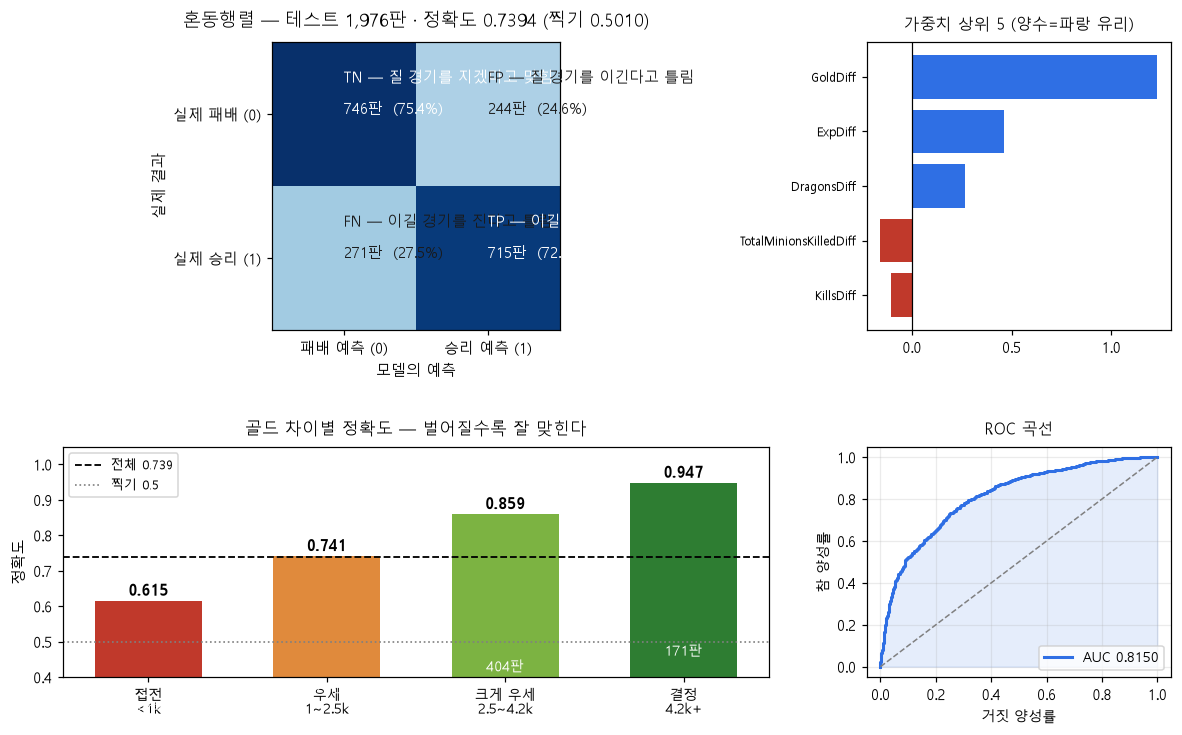

TN  746  질 경기를 지겠다고 맞힘
FP  244  질 경기를 이긴다고 틀림   ← 헛다리
FN  271  이길 경기를 진다고 틀림   ← 놓침
TP  715  이길 경기를 이기겠다고 맞힘


In [6]:
cm_table = pd.DataFrame(cm, index=["실제 패배 (0)", "실제 승리 (1)"],
                        columns=["패배 예측 (0)", "승리 예측 (1)"])
cm_table["합계"] = cm_table.sum(axis=1)
cm_table.loc["합계"] = cm_table.sum()
display(cm_table)

fig = plt.figure(figsize=(13, 7.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], hspace=0.45, wspace=0.32)

# 혼동행렬 — 경기 수와 비율을 한 칸에 함께
ax = fig.add_subplot(gs[0, :2])
ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
tags = [["TN — 질 경기를 지겠다고 맞힘", "FP — 질 경기를 이긴다고 틀림"],
        ["FN — 이길 경기를 진다고 틀림", "TP — 이길 경기를 이기겠다고 맞힘"]]
cmn = cm / cm.sum(axis=1, keepdims=True)
NL = chr(10)
for i in range(2):
    for j in range(2):
        ax.text(j, i, tags[i][j] + NL + NL + f"{cm[i, j]:,}판  ({cmn[i, j]:.1%})",
                color="white" if cm[i, j] > cm.max() * 0.6 else "#1a1a1a")
ax.set_xticks([0, 1]); ax.set_xticklabels(["패배 예측 (0)", "승리 예측 (1)"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 패배 (0)", "실제 승리 (1)"], fontsize=10)
ax.set_xlabel("모델의 예측"); ax.set_ylabel("실제 결과")
ax.set_title(f"혼동행렬 — 테스트 {len(y_te):,}판 · 정확도 {acc:.4f} (찍기 {baseline:.4f})", fontsize=12, pad=10)

# 가중치 상위 5
ax = fig.add_subplot(gs[0, 2])
t5 = coef.head(5)[::-1]
ax.barh(range(len(t5)), t5.values, color=["#2f6fe4" if v > 0 else "#c0392b" for v in t5])
ax.set_yticks(range(len(t5))); ax.set_yticklabels(t5.index, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("가중치 상위 5 (양수=파랑 유리)", fontsize=10.5, pad=8)

# 구간별 정확도
ax = fig.add_subplot(gs[1, :2])
ax.bar(range(len(seg)), seg["정확도"], color=["#c0392b", "#e08a3c", "#7cb342", "#2e7d32"], width=0.6)
for i, (v, n) in enumerate(zip(seg["정확도"], seg["경기수"])):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=10.5, fontweight="bold")
    ax.text(i, v / 2, f"{n}판", ha="center", va="center", fontsize=9, color="white")
ax.axhline(acc, color="black", ls="--", lw=1.2, label=f"전체 {acc:.3f}")
ax.axhline(0.5, color="gray", ls=":", lw=1.1, label="찍기 0.5")
ax.set_xticks(range(len(seg)))
ax.set_xticklabels(["접전" + NL + "<1k", "우세" + NL + "1~2.5k", "크게 우세" + NL + "2.5~4.2k", "결정" + NL + "4.2k+"], fontsize=9)
ax.set_ylim(0.4, 1.05); ax.set_ylabel("정확도")
ax.set_title("골드 차이별 정확도 — 벌어질수록 잘 맞힌다", fontsize=11, pad=8)
ax.legend(loc="upper left", fontsize=8.5)

# ROC
ax = fig.add_subplot(gs[1, 2])
fpr, tpr, _ = roc_curve(y_te, proba)
ax.plot(fpr, tpr, lw=2, color="#2f6fe4", label=f"AUC {auc:.4f}")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax.fill_between(fpr, tpr, alpha=0.12, color="#2f6fe4")
ax.set_xlabel("거짓 양성률", fontsize=9); ax.set_ylabel("참 양성률", fontsize=9)
ax.set_title("ROC 곡선", fontsize=10.5, pad=8)
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.25)

plt.show()

print(f"TN {tn:>4}  질 경기를 지겠다고 맞힘")
print(f"FP {fp:>4}  질 경기를 이긴다고 틀림   ← 헛다리")
print(f"FN {fn:>4}  이길 경기를 진다고 틀림   ← 놓침")
print(f"TP {tp:>4}  이길 경기를 이기겠다고 맞힘")

**읽는 법** — 대각선(TN·TP)이 맞힌 것, 나머지가 틀린 것입니다.

**틀린 방향이 244 대 271로 거의 같습니다.** 한쪽으로 치우쳐 틀리지 않는다는 뜻이고,
승패 어느 쪽도 편들지 않는 모델이라는 근거입니다. 비율로 보면 실제 패배의 75.4%,
실제 승리의 72.5%를 맞혀 두 값이 비슷합니다.

---

### 정리

| 항목 | 결과 |
|---|---|
| 채택 모델 | 로지스틱 회귀 (8종 중 1위, 과적합 없음, 설명 가능) |
| 데이터·분할 | 9,879판 → 학습 7,903 / 시험 1,976 (층화·시드 42·겹침 0) |
| 뷰 | `v_diff13_train` / `v_diff13_test` (지표 13개) |
| **정확도** | **0.7394** (찍기 0.5010 대비 +23.8%p) · 반복 0.7366 ± 0.0081 |
| F1 / AUC / Brier | 0.7352 / 0.8150 / 0.1756 |
| **혼동행렬** | **TN 746 · FP 244 / FN 271 · TP 715** |
| 한계 | 접전 구간(34%) 0.615 — 10분 정보 자체의 한계 |

재현: `python src/finalize_model.py` · `python src/repeat_check.py`